Fitting 3 folds for each of 50 candidates, totalling 150 fits


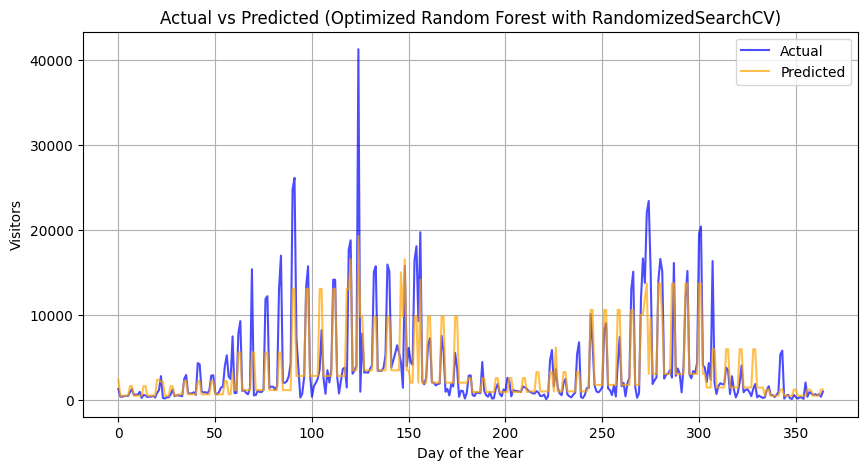

Best Parameters: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 15, 'n_estimators': 186}
Mean Absolute Error (Original Scale): 1630.26
R² Score (Original Scale): 0.64


In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from scipy.stats import randint

#######최종정리########


import pandas as pd
from datetime import datetime

# 1. 공휴일 및 대체공휴일 정의 함수
def get_holidays(year):
    holidays_dict = {
        2018: [
            '2018-01-01', '2018-02-15', '2018-02-16', '2018-02-17',  # 신정, 설날 연휴
            '2018-03-01', '2018-05-01', '2018-05-05', '2018-05-07',  # 삼일절, 근로자의날, 어린이날, 대체공휴일
            '2018-06-06', '2018-08-15', '2018-09-23', '2018-09-24', '2018-09-25',  # 현충일, 광복절, 추석 연휴
            '2018-10-03', '2018-10-09', '2018-12-25'                # 개천절, 한글날, 성탄절
        ],
        2019: [
            '2019-01-01', '2019-02-04', '2019-02-05', '2019-02-06',  # 신정, 설날 연휴
            '2019-03-01', '2019-05-01', '2019-05-05', '2019-05-06',  # 삼일절, 근로자의날, 어린이날, 대체공휴일
            '2019-06-06', '2019-08-15', '2019-09-12', '2019-09-13', '2019-09-14',  # 현충일, 광복절, 추석 연휴
            '2019-10-03', '2019-10-09', '2019-12-25'                # 개천절, 한글날, 성탄절
        ],
        2020: [
            '2020-01-01', '2020-01-24', '2020-01-25', '2020-01-26', '2020-01-27',  # 신정, 설날 연휴 및 대체공휴일
            '2020-03-01', '2020-04-15', '2020-05-01', '2020-05-05',  # 삼일절, 총선, 근로자의날, 어린이날
            '2020-06-06', '2020-08-15', '2020-09-30', '2020-10-01', '2020-10-02',  # 현충일, 광복절, 추석 연휴
            '2020-10-03', '2020-10-09', '2020-12-25'                # 개천절, 한글날, 성탄절
        ],
        2021: [
            '2021-01-01', '2021-02-11', '2021-02-12', '2021-02-13',  # 신정, 설날 연휴
            '2021-03-01', '2021-05-01', '2021-05-05', '2021-05-19',  # 삼일절, 근로자의날, 어린이날, 부처님오신날
            '2021-06-06', '2021-08-15', '2021-08-16',               # 현충일, 광복절, 대체공휴일
            '2021-09-20', '2021-09-21', '2021-09-22',               # 추석 연휴
            '2021-10-03', '2021-10-04', '2021-10-09', '2021-12-25'  # 개천절(대체), 한글날, 성탄절
        ],
        2022: [
            '2022-01-01', '2022-01-31', '2022-02-01', '2022-02-02',  # 신정, 설날 연휴
            '2022-03-01', '2022-05-01', '2022-05-05', '2022-05-08', '2022-05-09',  # 삼일절, 근로자의날, 어린이날, 부처님오신날, 대체공휴일
            '2022-06-06', '2022-08-15',                              # 현충일, 광복절
            '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12',  # 추석 연휴 및 대체공휴일
            '2022-10-03', '2022-10-09', '2022-10-10', '2022-12-25'   # 개천절, 한글날, 대체공휴일, 성탄절
        ],
        2023: [
            '2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',  # 신정, 설날 연휴 및 대체공휴일
            '2023-03-01', '2023-05-01', '2023-05-05', '2023-05-27', '2023-05-29',  # 삼일절, 근로자의날, 어린이날, 부처님오신날 및 대체공휴일
            '2023-06-06', '2023-08-15',                              # 현충일, 광복절
            '2023-09-28', '2023-09-29', '2023-09-30', '2023-10-03',  # 추석 연휴 및 개천절
            '2023-10-09', '2023-12-25'                               # 한글날, 성탄절
        ]
    }


    return [datetime.strptime(date, '%Y-%m-%d') for date in holidays_dict[year]]

# 2. 공휴일 추가 및 전처리 함수
def add_holiday_column(df, year):
    holiday_dates = get_holidays(year)
    df['date'] = pd.to_datetime(df['date'])
    df['is_holiday'] = df['date'].apply(lambda x: 1 if x in holiday_dates else 0)
    return df

# 3. 데이터 로드 및 전처리
file_paths = {
    2018: '서울대공원_입장객_정보_2018년_day_한글복원2.csv',
    2019: '서울대공원_입장객_정보_2019년_day_한글복원 (1).csv',
    2020: '서울대공원_입장객_정보_2020년_day_한글복원_new.csv',
    2021: '서울대공원_입장객_정보_2021년_day_한글복원.csv',
    2022: '서울대공원_입장객_정보_2022년_day_한글복원.csv',
    2023: '서울대공원_입장객_정보_2023년_day_한글복원.csv'
}
# 데이터 로드 및 전처리
data_frames = []
for year, path in file_paths.items():
    try:
        df = pd.read_csv(path, encoding='cp949')  # 파일 인코딩 확인
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding='utf-8')
    df = add_holiday_column(df, year)
    df['year'] = int(year)
    data_frames.append(df)

data = pd.concat(data_frames)

# 'day' 컬럼을 숫자로 변환 (월~일 -> 평일/주말 구분)
day_mapping = {'월': 0, '화': 0, '수': 0, '목': 0, '금': 0, '토': 1, '일': 1}
data['day_numeric'] = data['day'].map(day_mapping)

# 날짜로부터 월(month) 컬럼 추출
data['date'] = pd.to_datetime(data['date'])
data['month'] = data['date'].dt.month


# 어린이날 여부 추가
data['is_childrens_day'] = ((data['date'].dt.month == 5) & (data['date'].dt.day == 5)).astype(int)

# # 설명변수(X)와 종속변수(y) 정의
X = data[['month', 'day_numeric', 'is_holiday', 'is_childrens_day']]
y = data['individual_visitors']


# 학습 데이터셋(2023년 이전)과 테스트 데이터셋(2023년) 분리
X_train = X[data['year'] < 2023]
X_test = X[data['year'] == 2023]
y_train = y[data['year'] < 2023]
y_test = y[data['year'] == 2023]

# 로그 변환
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

# RandomizedSearchCV 설정
param_distributions = {
    'n_estimators': randint(100, 500),  # 트리 개수 범위
    'max_depth': [5, 10, 15, None],  # 최대 깊이
    'min_samples_split': randint(2, 20),  # 노드 분할 최소 샘플 수
    'min_samples_leaf': randint(1, 10),  # 리프 노드 최소 샘플 수
    'max_features': ['sqrt', 'log2', None]  # 분할 시 고려할 특성 수
}

random_search = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                                   param_distributions=param_distributions,
                                   n_iter=50,  # 랜덤 탐색 횟수
                                   scoring='neg_mean_absolute_error',  # 평가 점수: MAE
                                   cv=3,  # 3-겹 교차 검증
                                   verbose=2,
                                   n_jobs=-1)  # 모든 CPU 코어 사용

# 모델 학습 및 최적 파라미터 탐색
random_search.fit(X_train, y_train)

# 최적 모델 및 파라미터 확인
best_model = random_search.best_estimator_
best_params = random_search.best_params_

# 최적화된 모델로 예측 수행
y_pred_best = best_model.predict(X_test)

# 로그 변환 해제 후 MAE 계산
y_test_exp = np.expm1(y_test)  # 로그 변환 해제
y_pred_best_exp = np.expm1(y_pred_best)  # 로그 변환 해제
mae_best = mean_absolute_error(y_test_exp, y_pred_best_exp)

# R² 계산
r2_best = r2_score(y_test_exp, y_pred_best_exp)

# 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(y_test_exp.values, label='Actual', color='blue', alpha=0.7)
plt.plot(y_pred_best_exp, label='Predicted', color='orange', alpha=0.7)
plt.legend()
plt.title('Actual vs Predicted (Optimized Random Forest with RandomizedSearchCV)')
plt.xlabel('Day of the Year')
plt.ylabel('Visitors')
plt.grid(True)
plt.show()

# 결과 출력
print(f"Best Parameters: {best_params}")
print(f"Mean Absolute Error (Original Scale): {mae_best:.2f}")
print(f"R² Score (Original Scale): {r2_best:.2f}")


In [2]:
# 훈련 데이터와 테스트 데이터에 대한 MAE 계산
y_train_pred = best_model.predict(X_train)
train_mae = mean_absolute_error(y_train, y_train_pred)

# 로그 변환을 되돌려 원래 단위로 MAE를 계산
y_test_exp = np.expm1(y_test)  # 로그 변환 해제
y_pred_best_exp = np.expm1(y_pred_best)  # 로그 변환 해제
mae_test_original = mean_absolute_error(y_test_exp, y_pred_best_exp)

y_train_exp = np.expm1(y_train)  # 로그 변환 해제
y_train_pred_exp = np.expm1(y_train_pred)  # 로그 변환 해제
mae_train_original = mean_absolute_error(y_train_exp, y_train_pred_exp)

# MAE 출력
print(f"Train MAE : {mae_train_original}")
print(f"Test MAE : {mae_test_original}")

# 과적합 여부 판단
if mae_train_original < mae_test_original * 0.8:
    print("The model is likely underfitting.")
elif mae_test_original > mae_train_original * 1.5:
    print("The model is likely overfitting.")
else:
    print("The model is performing well with no significant overfitting.")


Train MAE : 1978.1968581330848
Test MAE : 1630.2597908666548
The model is performing well with no significant overfitting.


In [3]:
from sklearn.metrics import r2_score

# R² 계산
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred_best)

# 로그 변환 해제 후 R² 계산 (원래 스케일에서의 예측력)
train_r2_original = r2_score(np.expm1(y_train), np.expm1(y_train_pred))
test_r2_original = r2_score(np.expm1(y_test), np.expm1(y_pred_best))

# R² 출력
print(f"Train R² (Log Scale): {train_r2:.2f}")
print(f"Test R² (Log Scale): {test_r2:.2f}")
print(f"Train R² (Original Scale): {train_r2_original:.2f}")
print(f"Test R² (Original Scale): {test_r2_original:.3}")


Train R² (Log Scale): 0.63
Test R² (Log Scale): 0.62
Train R² (Original Scale): 0.55
Test R² (Original Scale): 0.641
